In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
df = pd.read_csv(url)

print(df.shape)
df.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [2]:
# Basic info: column types, non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [3]:
# Descriptive stats for numeric columns
desc = df.describe()
desc

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)

,missing_count,missing_pct
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


In [5]:
df_clean = df.copy()

# Drop deck (too sparse)
df_clean = df_clean.drop(columns=['deck'])

# Fill age with median
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())

# Fill embarked/embark_town with mode
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])
df_clean['embark_town'] = df_clean['embark_town'].fillna(df_clean['embark_town'].mode()[0])

# Confirm no missing values remain
df_clean.isnull().sum().sum()

np.int64(0)

In [6]:
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

for col in ['fare', 'age']:
    lower, upper = iqr_bounds(df_clean[col])
    n_outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    print(f"{col}: lower={lower:.2f}, upper={upper:.2f}, outliers={n_outliers} ({n_outliers/len(df_clean)*100:.1f}%)")

fare: lower=-26.72, upper=65.63, outliers=116 (13.0%)
age: lower=2.50, upper=54.50, outliers=66 (7.4%)


In [7]:
df_clean2 = df_clean.copy()

for col in ['fare', 'age']:
    lower, upper = iqr_bounds(df_clean2[col])
    df_clean2[col] = df_clean2[col].clip(lower=lower, upper=upper)

# quick check - new max values should now match the upper bound
df_clean2[['fare', 'age']].describe()

,fare,age
count,891.000000,891.000000
mean,24.046813,29.039282
std,20.481625,12.072074
min,0.000000,2.500000
25%,7.910400,22.000000
50%,14.454200,28.000000
75%,31.000000,35.000000
max,65.634400,54.500000


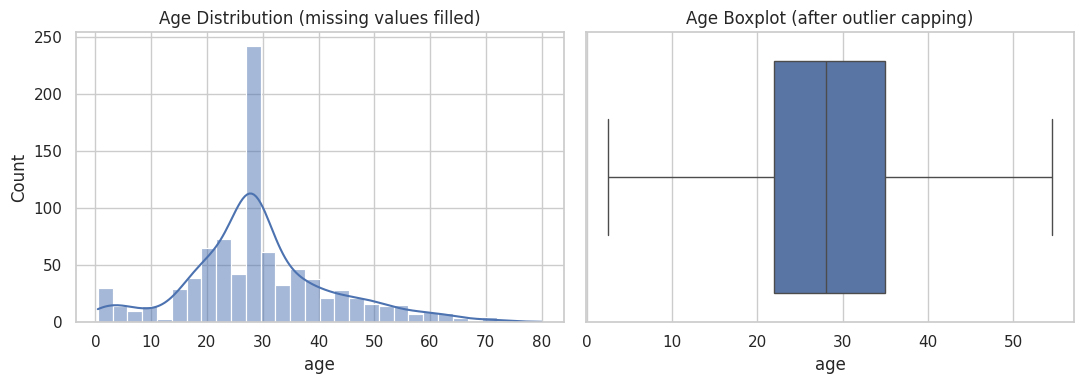

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(df_clean['age'], kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title("Age Distribution (missing values filled)")

sns.boxplot(x=df_clean2['age'], ax=axes[1], color='#4C72B0')
axes[1].set_title("Age Boxplot (after outlier capping)")

plt.tight_layout()
plt.show()

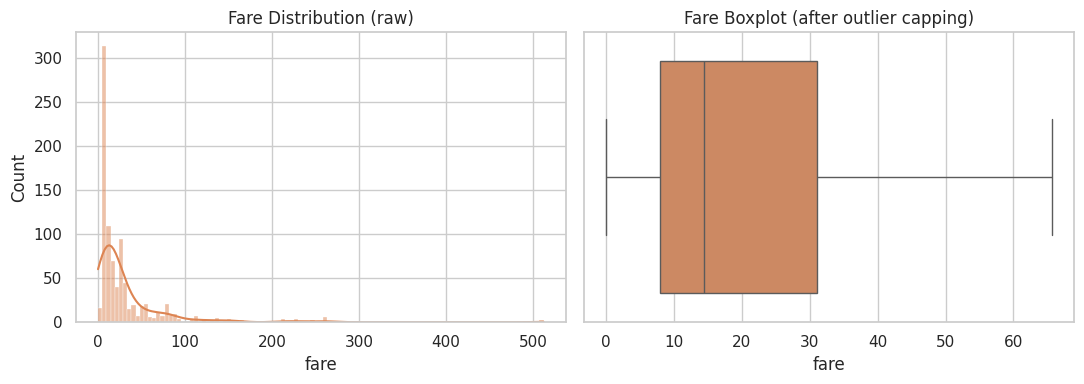

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(df_clean['fare'], kde=True, ax=axes[0], color='#DD8452')
axes[0].set_title("Fare Distribution (raw)")

sns.boxplot(x=df_clean2['fare'], ax=axes[1], color='#DD8452')
axes[1].set_title("Fare Boxplot (after outlier capping)")

plt.tight_layout()
plt.show()

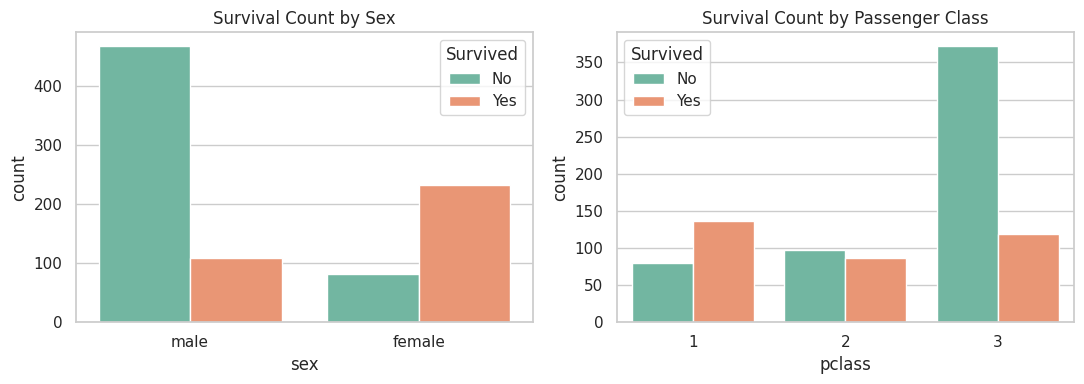

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(data=df_clean, x='sex', hue='survived', ax=axes[0], palette='Set2')
axes[0].set_title("Survival Count by Sex")
axes[0].legend(title='Survived', labels=['No', 'Yes'])

sns.countplot(data=df_clean, x='pclass', hue='survived', ax=axes[1], palette='Set2')
axes[1].set_title("Survival Count by Passenger Class")
axes[1].legend(title='Survived', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

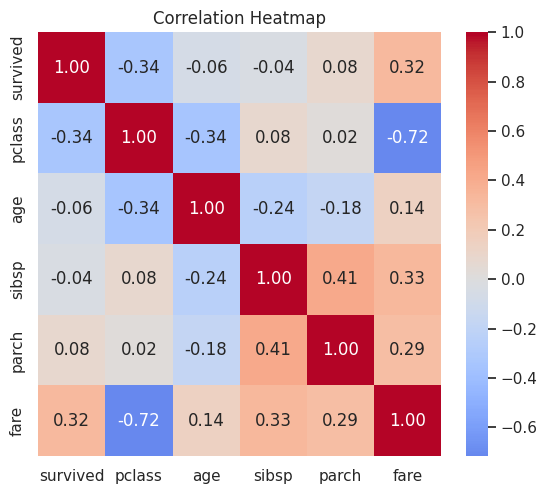

In [11]:
numeric_cols = df_clean2.select_dtypes(include='number').columns
corr = df_clean2[numeric_cols].corr()

plt.figure(figsize=(6.5, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [15]:
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages("EDA_Report.pdf") as pdf:

    # --- Page 1: Title + descriptive stats table ---
    fig, ax = plt.subplots(figsize=(8.5, 11))
    ax.axis('off')
    ax.text(0.5, 0.97, "Titanic Dataset — EDA Summary Report", fontsize=16, weight='bold', ha='center', transform=ax.transAxes)
    ax.text(0.5, 0.93, f"Rows: {df.shape[0]}   |   Columns: {df.shape[1]}", fontsize=10, ha='center', transform=ax.transAxes)

    ax.text(0.02, 0.87, "Descriptive Statistics", fontsize=12, weight='bold', transform=ax.transAxes)
    desc_table = df.describe().round(2)
    tbl1 = ax.table(cellText=desc_table.values, colLabels=desc_table.columns,
                     rowLabels=desc_table.index, loc='upper left',
                     bbox=[0.02, 0.60, 0.96, 0.25])
    tbl1.auto_set_font_size(False)
    tbl1.set_fontsize(7)

    ax.text(0.02, 0.55, "Missing Values (before cleaning)", fontsize=12, weight='bold', transform=ax.transAxes)
    miss_table = missing_summary[missing_summary['missing_count'] > 0]
    tbl2 = ax.table(cellText=miss_table.values, colLabels=miss_table.columns,
                     rowLabels=miss_table.index, loc='upper left',
                     bbox=[0.02, 0.42, 0.6, 0.12])
    tbl2.auto_set_font_size(False)
    tbl2.set_fontsize(7)

    ax.text(0.02, 0.36, "Handling: age -> median fill, embarked/embark_town -> mode fill, deck -> dropped (77% missing).",
            fontsize=8, transform=ax.transAxes, wrap=True)
    ax.text(0.02, 0.30, "Outliers (IQR method): capped at 1.5x IQR bounds for fare and age.",
            fontsize=8, transform=ax.transAxes, wrap=True)

    pdf.savefig(fig)
    plt.close(fig)

    # --- Page 2: Age distribution ---
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    sns.histplot(df_clean['age'], kde=True, ax=axes[0], color='#4C72B0')
    axes[0].set_title("Age Distribution")
    sns.boxplot(x=df_clean2['age'], ax=axes[1], color='#4C72B0')
    axes[1].set_title("Age Boxplot (capped)")
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

    # --- Page 3: Fare distribution ---
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    sns.histplot(df_clean['fare'], kde=True, ax=axes[0], color='#DD8452')
    axes[0].set_title("Fare Distribution")
    sns.boxplot(x=df_clean2['fare'], ax=axes[1], color='#DD8452')
    axes[1].set_title("Fare Boxplot (capped)")
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

    # --- Page 4: Correlation heatmap ---
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
    ax.set_title("Correlation Heatmap")
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

print("PDF report saved!")

PDF report saved!


In [16]:
from google.colab import files
files.download("EDA_Report.pdf")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>